# Modelo de Detección de Fraude Financiero
## Caso Integrador Final — Programa de Especialización en Credit Scoring con Python

**Escenario:** Una institución financiera requiere fortalecer su sistema de gestión de riesgo
operacional mediante un modelo de ML capaz de identificar transacciones anómalas (fraude).

**Variable objetivo:** `fraud` — binaria (0 = legítima, 1 = fraude), tasa de incidencia ~2%.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              f1_score, recall_score)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap
import joblib

RANDOM_STATE = 42
TEST_SIZE    = 0.20
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (10, 5)

print("Librerias cargadas correctamente.")
print("Notebook revisado: SMOTE/SMOTETomek viven dentro de ImbPipeline (sin data leakage en CV).")

Librerias cargadas correctamente.
Notebook revisado: SMOTE/SMOTETomek viven dentro de ImbPipeline (sin data leakage en CV).


In [35]:
df = pd.read_csv("../data/base.csv")
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Shape: (10000, 17)
Columnas: ['transaction_id', 'timestamp', 'amount', 'transaction_type', 'location', 'client_credit_score', 'transaction_frequency', 'customer_age', 'annual_income', 'account_balance', 'num_previous_loans', 'customer_tenure', 'num_dependents', 'education_level', 'marital_status', 'housing_type', 'fraud']


,transaction_id,timestamp,amount,transaction_type,location,client_credit_score,transaction_frequency,customer_age,annual_income,account_balance,num_previous_loans,customer_tenure,num_dependents,education_level,marital_status,housing_type,fraud
0,1,2023-01-11 23:15:00,31.705255,retiro,Region_D,582,4,32,39615.208376,87327.964032,0,4,5,4,viudo,familiar,0
1,2,2023-01-01 14:20:00,23.918016,transferencia,Region_C,455,3,21,44249.878473,71636.227027,9,18,0,1,divorciado,propia,0
2,3,2023-01-27 11:58:00,92.529562,transferencia,Region_C,479,2,30,37617.570952,82196.011244,5,27,2,2,soltero,propia,1
3,4,2023-01-08 20:04:00,70.041339,pago,Region_C,386,5,46,51472.479789,74139.750178,0,20,4,4,viudo,familiar,0
4,5,2023-01-05 08:25:00,201.800781,transferencia,Region_A,705,4,67,46632.454229,30783.511996,10,17,5,1,divorciado,propia,0


## Módulo 1: Análisis Exploratorio de Datos (EDA)

> "Un buen modelo no nace en el algoritmo, nace en el EDA.".

El EDA es la base diagnóstica que justifica todas las decisiones técnicas posteriores.
Se analiza la calidad de los datos, el desbalance de clases, la distribución de variables
y el comportamiento diferenciado entre transacciones legítimas y fraudulentas.

In [36]:
print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
display(df.describe(percentiles=[.25, .50, .75, .90, .99]).round(2))

print("=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else "No se encontraron valores nulos.")
print(f"Tipos de datos:{df.dtypes}")

=== ESTADÍSTICOS DESCRIPTIVOS ===


,transaction_id,amount,client_credit_score,transaction_frequency,customer_age,annual_income,account_balance,num_previous_loans,customer_tenure,num_dependents,education_level,fraud
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,109.74,574.19,3.14,54.01,50896.02,54414.97,5.15,14.90,2.03,2.49,0.02
std,2886.90,181.91,163.38,2.26,21.80,22719.30,58969.64,3.49,9.03,1.44,1.12,0.14
min,1.00,0.01,150.00,0.00,5.00,32.71,9.79,0.00,0.00,0.00,1.00,0.00
25%,2500.75,29.63,435.00,2.00,35.00,36384.64,25374.58,2.00,7.00,1.00,1.00,0.00
50%,5000.50,69.75,572.00,3.00,54.00,50220.81,50930.53,5.00,15.00,2.00,2.00,0.00
75%,7500.25,138.13,714.00,4.00,73.00,63896.02,75560.06,8.00,23.00,3.00,4.00,0.00
90%,9000.10,234.98,799.00,5.00,83.00,76123.04,90580.68,10.00,27.00,4.00,4.00,0.00
99%,9900.01,554.42,847.00,9.00,90.00,108098.62,99899.47,10.10,30.00,6.00,4.00,1.00
max,10000.00,5705.57,950.00,35.00,120.00,289309.44,996031.84,20.00,30.00,9.00,4.00,1.00


=== VALORES NULOS ===
No se encontraron valores nulos.
Tipos de datos:transaction_id             int64
timestamp                    str
amount                   float64
transaction_type             str
location                     str
client_credit_score        int64
transaction_frequency      int64
customer_age               int64
annual_income            float64
account_balance          float64
num_previous_loans         int64
customer_tenure            int64
num_dependents             int64
education_level            int64
marital_status               str
housing_type                 str
fraud                      int64
dtype: object


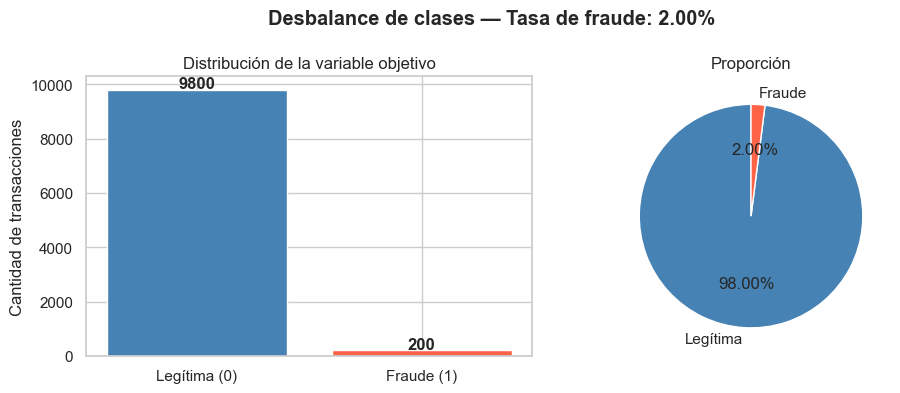

9,800 legítimas vs 200 fraudes (2.00%)
Estrategia requerida: SMOTE + métricas Recall/F1 (no Accuracy global)


In [37]:
conteo     = df['fraud'].value_counts()
pct_fraude = df['fraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Legítima (0)', 'Fraude (1)'], conteo.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_ylabel('Cantidad de transacciones')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['Legítima', 'Fraude'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción')

plt.suptitle(f'Desbalance de clases — Tasa de fraude: {pct_fraude:.2f}%',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{conteo[0]:,} legítimas vs {conteo[1]:,} fraudes ({pct_fraude:.2f}%)")
print("Estrategia requerida: SMOTE + métricas Recall/F1 (no Accuracy global)")

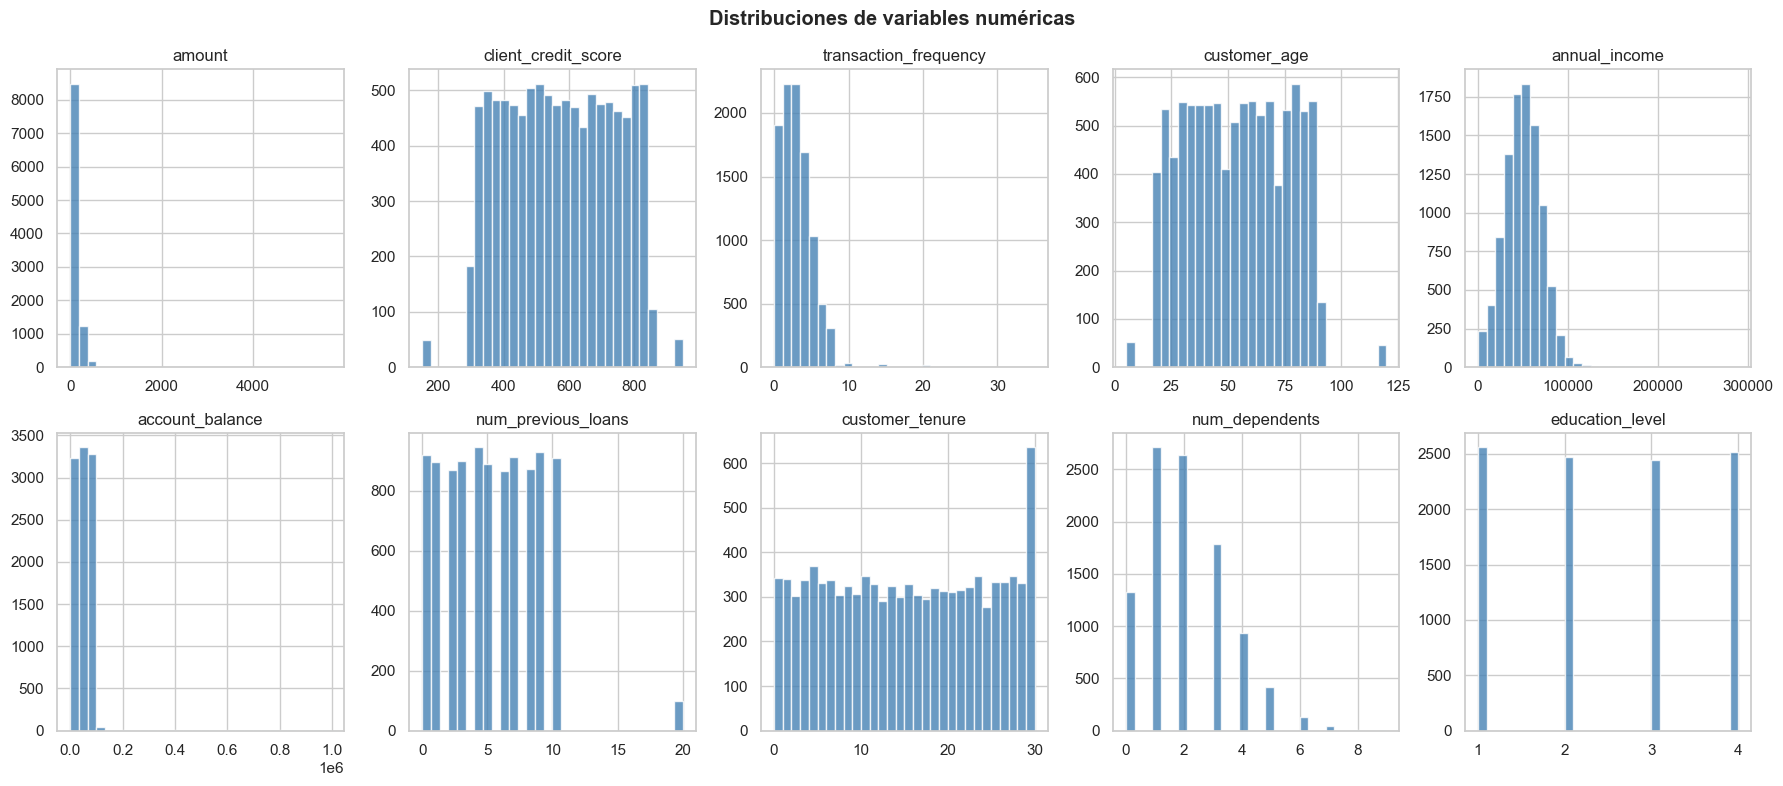

In [38]:
num_cols = ['amount', 'client_credit_score', 'transaction_frequency',
            'customer_age', 'annual_income', 'account_balance',
            'num_previous_loans', 'customer_tenure', 'num_dependents',
            'education_level']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
plt.suptitle('Distribuciones de variables numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

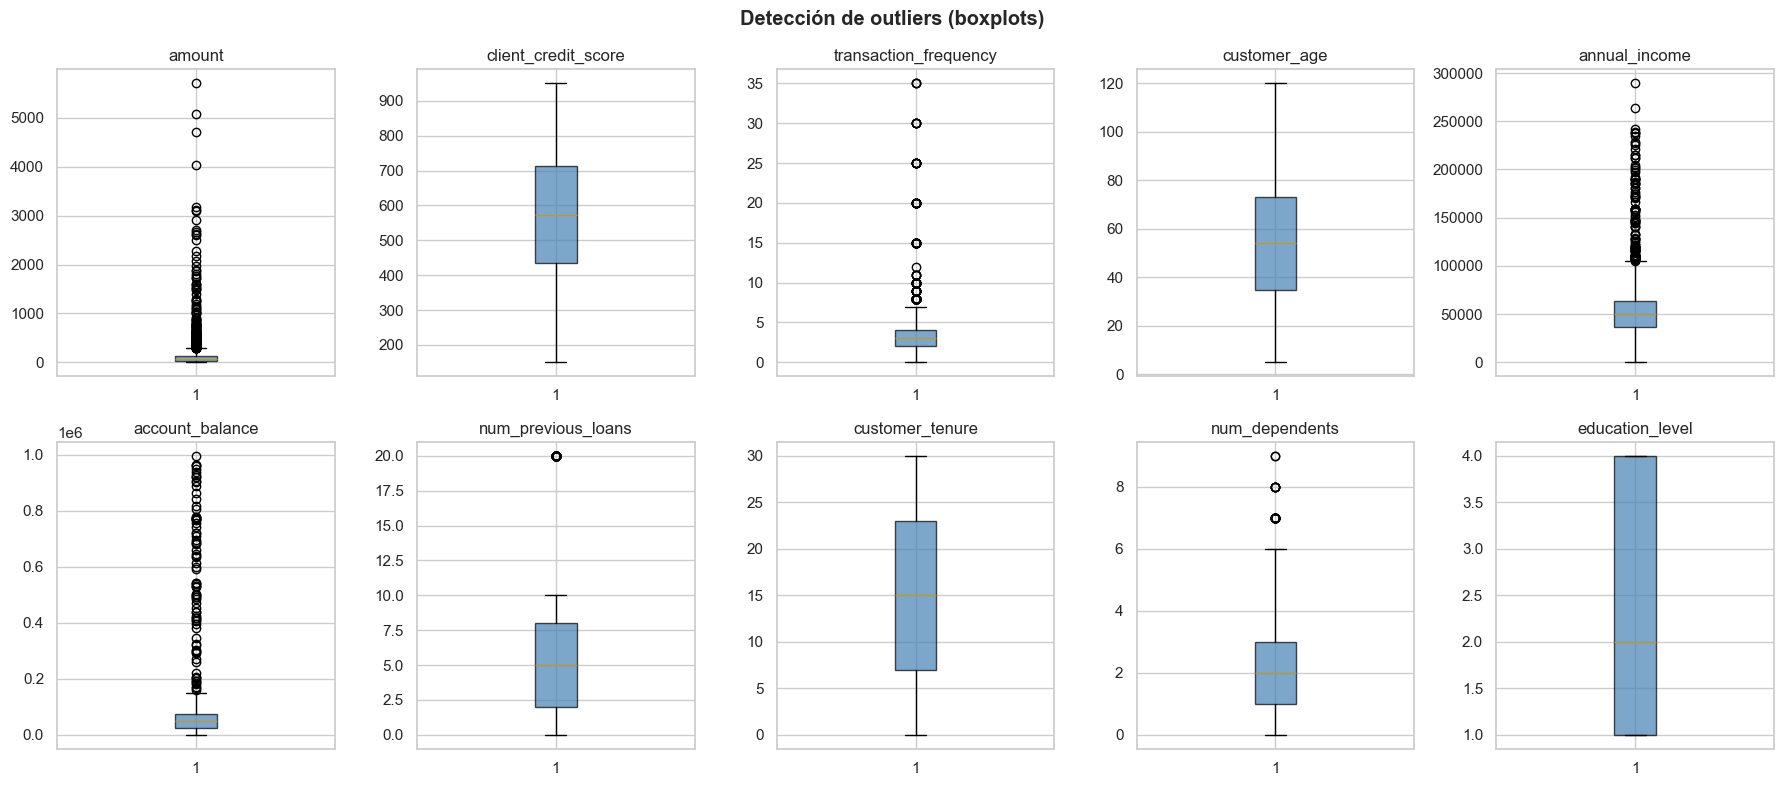

No se eliminan registros. Outliers reales se conservan mediante Winsorización al p99.


In [39]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
plt.suptitle('Detección de outliers (boxplots)', fontweight='bold')
plt.tight_layout()
plt.show()
print('No se eliminan registros. Outliers reales se conservan mediante Winsorización al p99.')

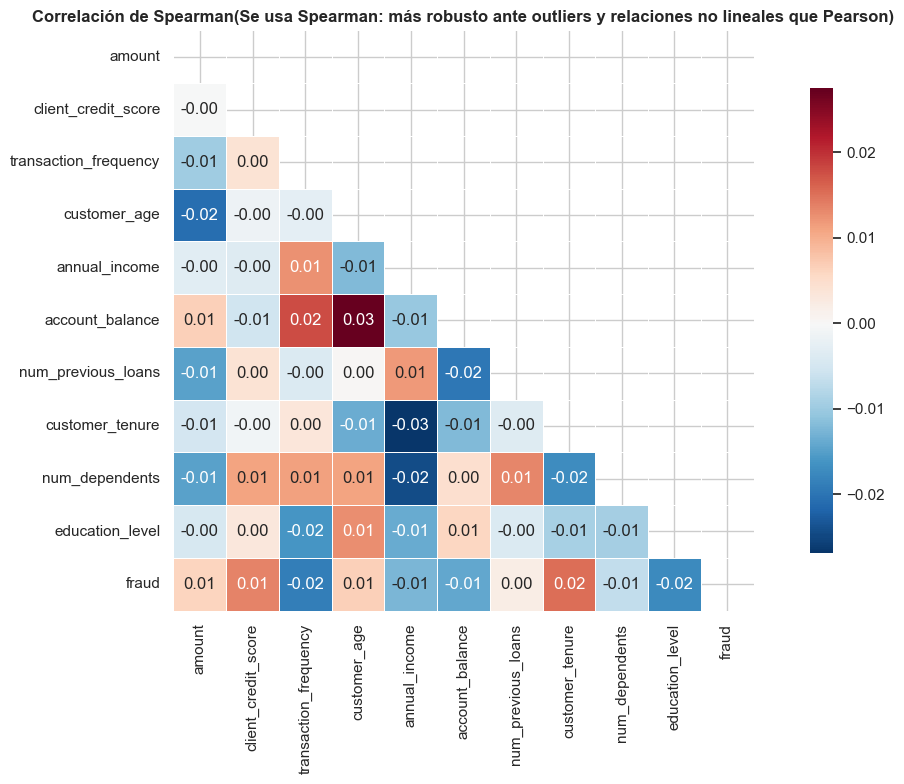

In [40]:
corr = df[num_cols + ['fraud']].corr(method='spearman')

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlación de Spearman'
          '(Se usa Spearman: más robusto ante outliers y relaciones no lineales que Pearson)',
          fontweight='bold')
plt.tight_layout()
plt.show()

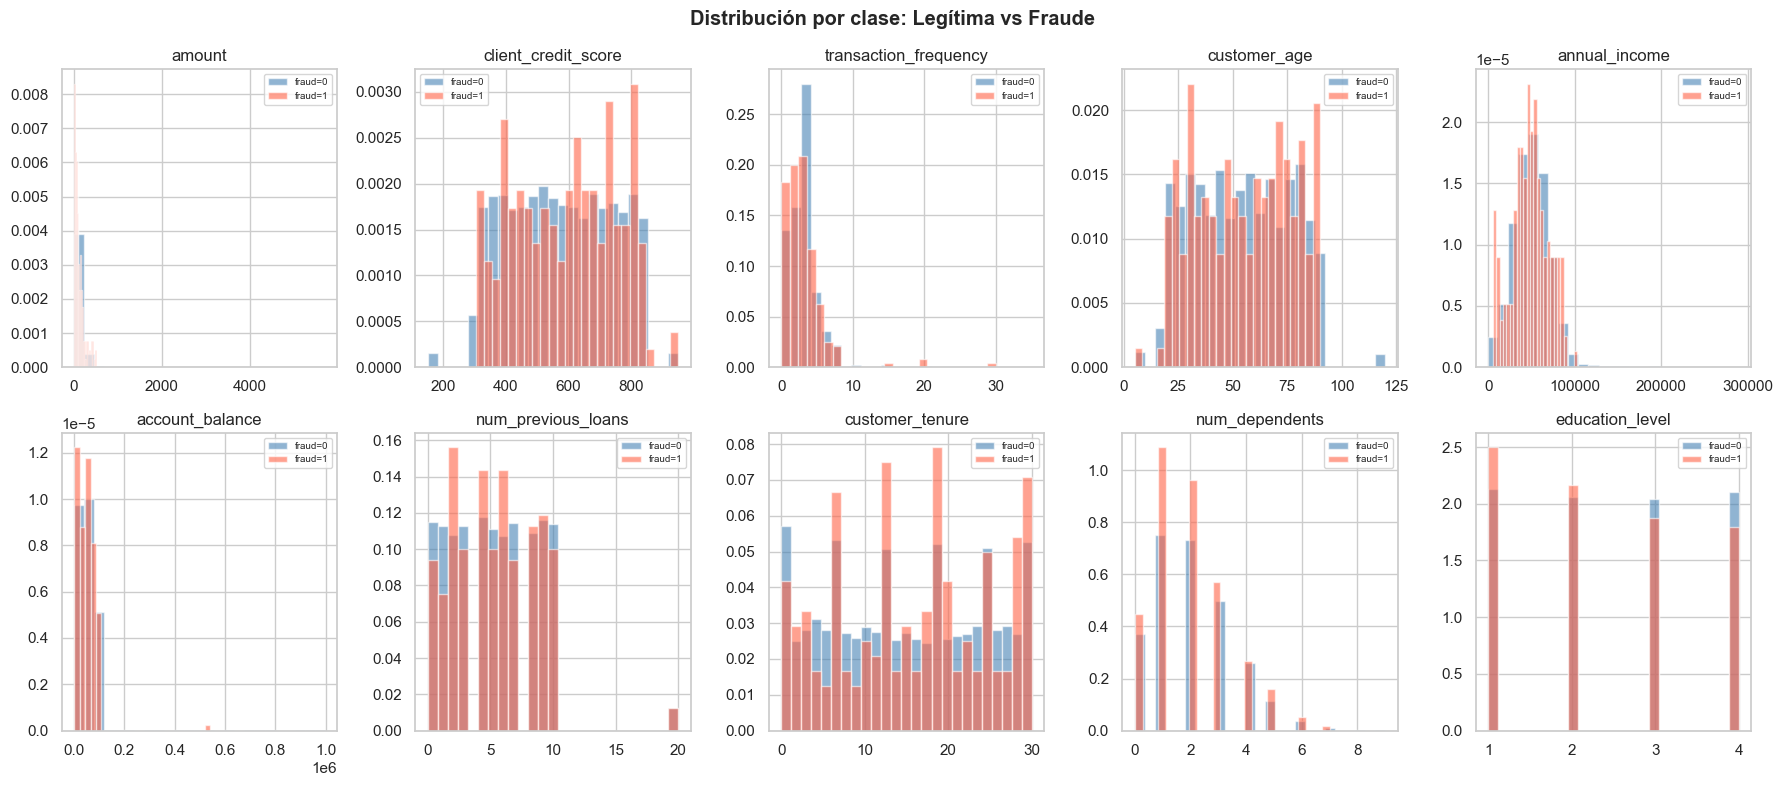

In [41]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df['fraud'] == label][col]
        axes[i].hist(subset, bins=25, alpha=0.6, density=True,
                     label=f'fraud={label}', color=color)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
plt.suptitle('Distribución por clase: Legítima vs Fraude', fontweight='bold')
plt.tight_layout()
plt.show()

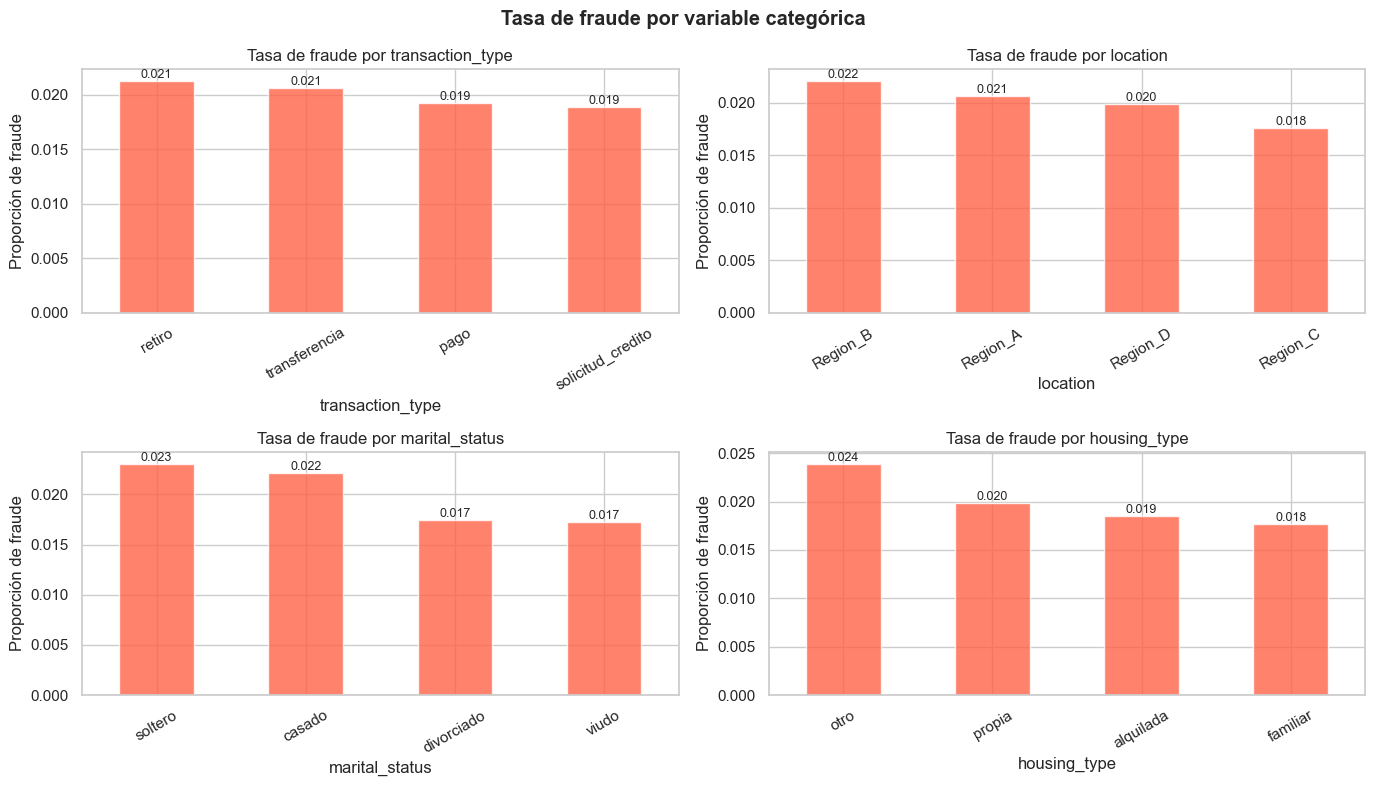

In [42]:
cat_cols = ['transaction_type', 'location', 'marital_status', 'housing_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    tasa = df.groupby(col)['fraud'].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', ax=axes[i], color='tomato', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Tasa de fraude por {col}')
    axes[i].set_ylabel('Proporción de fraude')
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=9)
plt.suptitle('Tasa de fraude por variable categórica', fontweight='bold')
plt.tight_layout()
plt.show()

## Módulo 2: Preprocesamiento de Datos

**Regla de oro anti data leakage:** La división Train/Test se realiza PRIMERO.
Ninguna transformación (escalado, SMOTE, imputación, Winsorización) se aplica antes
de esta división. Los transformadores se ajustan exclusivamente sobre el conjunto de
entrenamiento (`.fit_transform()`) y luego se aplican al de prueba (`.transform()`).

In [43]:
df['timestamp']  = pd.to_datetime(df['timestamp'])
df['hora']        = df['timestamp'].dt.hour
df['dia_semana']  = df['timestamp'].dt.dayofweek   # 0=lunes, 6=domingo
df['mes']         = df['timestamp'].dt.month

df = df.drop(columns=['transaction_id', 'timestamp'])

print("Feature engineering completado.")
print(f"Nuevas columnas: hora, dia_semana, mes")
print(f"Shape actualizado: {df.shape}")

Feature engineering completado.
Nuevas columnas: hora, dia_semana, mes
Shape actualizado: (10000, 18)


In [44]:
X = df.drop(columns=['fraud'])
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} | Fraudes: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test:  {X_test.shape[0]:,}  | Fraudes: {y_test.sum()}  ({y_test.mean()*100:.2f}%)")
print("stratify=y garantiza la misma proporción de fraude en ambos conjuntos.")

Train: 8,000 | Fraudes: 160 (2.00%)
Test:  2,000  | Fraudes: 40  (2.00%)
stratify=y garantiza la misma proporción de fraude en ambos conjuntos.


In [45]:
num_features = ['amount', 'client_credit_score', 'transaction_frequency',
                'customer_age', 'annual_income', 'account_balance',
                'num_previous_loans', 'customer_tenure', 'num_dependents',
                'education_level', 'hora', 'dia_semana', 'mes']

cat_features = ['transaction_type', 'location', 'marital_status', 'housing_type']

print(f"Variables numéricas ({len(num_features)}): {num_features}")
print(f"Variables categóricas ({len(cat_features)}): {cat_features}")
print("education_level ya viene codificada ordinalmente (1-4), se trata como numérica.")

Variables numéricas (13): ['amount', 'client_credit_score', 'transaction_frequency', 'customer_age', 'annual_income', 'account_balance', 'num_previous_loans', 'customer_tenure', 'num_dependents', 'education_level', 'hora', 'dia_semana', 'mes']
Variables categóricas (4): ['transaction_type', 'location', 'marital_status', 'housing_type']
education_level ya viene codificada ordinalmente (1-4), se trata como numérica.


In [46]:
winsor_limits = {}
for col in ['amount', 'annual_income', 'account_balance']:
    p99 = X_train[col].quantile(0.99)
    winsor_limits[col] = p99
    X_train[col] = X_train[col].clip(upper=p99)
    X_test[col]  = X_test[col].clip(upper=p99)

print("Winsorización al p99 aplicada:")
for col, lim in winsor_limits.items():
    print(f"  {col}: límite superior = {lim:,.2f}")
print("Se conservan todos los registros. Solo se acotan valores extremos.")
print("El límite se calcula sobre train y se aplica al test (anti data leakage).")

Winsorización al p99 aplicada:
  amount: límite superior = 541.90
  annual_income: límite superior = 109,041.26
  account_balance: límite superior = 99,955.58
Se conservan todos los registros. Solo se acotan valores extremos.
El límite se calcula sobre train y se aplica al test (anti data leakage).


In [47]:
preprocessor = ColumnTransformer(transformers=[
    ('num', SkPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), num_features),
    ('cat', SkPipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(drop='first', sparse_output=False,
                                  handle_unknown='ignore'))
    ]), cat_features)
])

print("ColumnTransformer definido.")
print("StandardScaler incluido para Regresión Logística.")
print("RF y XGBoost no lo requieren, pero no afecta su desempeño.")

ColumnTransformer definido.
StandardScaler incluido para Regresión Logística.
RF y XGBoost no lo requieren, pero no afecta su desempeño.


In [48]:
X_train_prep = preprocessor.fit_transform(X_train, y_train)
X_test_prep  = preprocessor.transform(X_test)

print(f"X_train_prep shape: {X_train_prep.shape}")
print(f"X_test_prep shape:  {X_test_prep.shape}")
print("fit_transform() solo en train. .transform() en test.")

X_train_prep shape: (8000, 25)
X_test_prep shape:  (2000, 25)
fit_transform() solo en train. .transform() en test.


## Módulo 3: Estrategia ante Desbalance y Construcción del Modelo

### Correcciones críticas aplicadas

1. **Pipeline imblearn dentro del CV.** SMOTE / SMOTETomek viven dentro de un
   `ImbPipeline([preprocessor, sampler, classifier])`. Así el sampler solo ve el train
   interno de cada fold y el validation queda con la distribución real (~2% fraude).
2. **Comparación de 3 estrategias de desbalance** por modelo (3 × 3 = 9 configuraciones):
   - `class_weight='balanced'` (LR/RF) y `scale_pos_weight = neg/pos` (XGB) — **sin sintéticos**
   - `SMOTE conservador` con `k_neighbors=3` — menos "fraudes fantasma"
   - `SMOTETomek` — sobremuestreo SMOTE + limpieza Tomek de pares ambiguos
3. **Scoring del CV: `average_precision` (AUC-PR)** en lugar de `f1`. AUC-PR integra todos
   los umbrales y es el estándar para clases muy desbalanceadas. F1 con umbral 0.5 fijo
   es inestable y oculta el problema.
4. **Selección final por AUC-PR en TEST** (no por F1-CV inflado) + **Principio de Parsimonia**:
   si la mejor RL queda a ≤ 0.01 en AUC-PR del top, se selecciona RL.

In [49]:
neg_pos_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"Relación neg/pos en train = {neg_pos_ratio:.1f}")
print("El sampler vive dentro del Pipeline imblearn de cada modelo y se ajusta")
print("solo sobre el train interno de cada fold. El test queda con la distribución real (~2%).")

Relación neg/pos en train = 49.0
El sampler vive dentro del Pipeline imblearn de cada modelo y se ajusta
solo sobre el train interno de cada fold. El test queda con la distribución real (~2%).


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("StratifiedKFold(5) definido.")
print("Preserva la proporción de clases en cada fold durante el ajuste de hiperparámetros.")

StratifiedKFold(5) definido.
Preserva la proporción de clases en cada fold durante el ajuste de hiperparámetros.


In [51]:
# ============================================================
# BÚSQUEDA 3 MODELOS x 3 ESTRATEGIAS = 9 CONFIGURACIONES
# - sampler dentro del Pipeline imblearn (sin data leakage en CV)
# - scoring='average_precision' (AUC-PR, estándar para clases raras)
# ============================================================

NOMBRE_MODELO = {'LR': 'Regresión Logística', 'RF': 'Random Forest', 'XGB': 'XGBoost'}
ESTRATEGIAS = ['class_weight', 'SMOTE_k3', 'SMOTETomek']

PARAM_GRID = {
    'LR':  {'classifier__C': [0.01, 0.1, 1, 10]},
    'RF':  {'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [5, 10, 15, None],
            'classifier__min_samples_leaf': [1, 2, 5]},
    'XGB': {'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'classifier__subsample': [0.7, 0.8, 1.0],
            'classifier__colsample_bytree': [0.7, 0.8, 1.0]},
}
N_ITER = {'LR': 4, 'RF': 10, 'XGB': 10}

def construir_sampler(estrategia):
    if estrategia == 'class_weight': return 'passthrough'
    if estrategia == 'SMOTE_k3':     return SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
    if estrategia == 'SMOTETomek':   return SMOTETomek(random_state=RANDOM_STATE)
    raise ValueError(estrategia)

def construir_clasificador(modelo_clave, estrategia):
    use_cw = estrategia == 'class_weight'
    if modelo_clave == 'LR':
        return LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                  class_weight='balanced' if use_cw else None)
    if modelo_clave == 'RF':
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                      class_weight='balanced' if use_cw else None)
    if modelo_clave == 'XGB':
        return xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss',
                                 scale_pos_weight=neg_pos_ratio if use_cw else 1.0,
                                 tree_method='hist')
    raise ValueError(modelo_clave)

resultados_cv = []
mejores_estimadores = {'LR': {}, 'RF': {}, 'XGB': {}}

for clave in ['LR', 'RF', 'XGB']:
    print(f"\n=== {NOMBRE_MODELO[clave]} ===")
    for est in ESTRATEGIAS:
        pipe = ImbPipeline([
            ('preprocessor', preprocessor),
            ('sampler',      construir_sampler(est)),
            ('classifier',   construir_clasificador(clave, est)),
        ])
        search = RandomizedSearchCV(
            pipe, PARAM_GRID[clave], n_iter=N_ITER[clave], cv=cv,
            scoring='average_precision', refit=True,
            random_state=RANDOM_STATE, n_jobs=-1, error_score='raise'
        )
        search.fit(X_train, y_train)
        proba_test = search.best_estimator_.predict_proba(X_test)[:, 1]
        ap_test  = average_precision_score(y_test, proba_test)
        auc_test = roc_auc_score(y_test, proba_test)
        resultados_cv.append({
            'Modelo': NOMBRE_MODELO[clave], 'Estrategia': est,
            'AUC-PR_CV': search.best_score_,
            'AUC-PR_Test': ap_test, 'AUC-ROC_Test': auc_test,
            'Hiperparámetros': search.best_params_,
        })
        mejores_estimadores[clave][est] = search.best_estimator_
        print(f"  {est:<14s} | CV AUC-PR={search.best_score_:.4f} | "
              f"Test AUC-PR={ap_test:.4f} | Test AUC-ROC={auc_test:.4f}")

df_cv = pd.DataFrame(resultados_cv)
print("\n=== TABLA COMPARATIVA (9 configuraciones) ===")
display(df_cv[['Modelo', 'Estrategia', 'AUC-PR_CV', 'AUC-PR_Test', 'AUC-ROC_Test']]
        .round(4)
        .style.background_gradient(subset=['AUC-PR_Test', 'AUC-ROC_Test'], cmap='RdYlGn'))


=== Regresión Logística ===


  class_weight   | CV AUC-PR=0.0230 | Test AUC-PR=0.0207 | Test AUC-ROC=0.4324
  SMOTE_k3       | CV AUC-PR=0.0306 | Test AUC-PR=0.0237 | Test AUC-ROC=0.4236
  SMOTETomek     | CV AUC-PR=0.0311 | Test AUC-PR=0.0242 | Test AUC-ROC=0.4487

=== Random Forest ===
  class_weight   | CV AUC-PR=0.0314 | Test AUC-PR=0.0280 | Test AUC-ROC=0.5086
  SMOTE_k3       | CV AUC-PR=0.0257 | Test AUC-PR=0.0178 | Test AUC-ROC=0.4316
  SMOTETomek     | CV AUC-PR=0.0256 | Test AUC-PR=0.0180 | Test AUC-ROC=0.4442

=== XGBoost ===
  class_weight   | CV AUC-PR=0.0361 | Test AUC-PR=0.0244 | Test AUC-ROC=0.5122
  SMOTE_k3       | CV AUC-PR=0.0282 | Test AUC-PR=0.0241 | Test AUC-ROC=0.5256
  SMOTETomek     | CV AUC-PR=0.0285 | Test AUC-PR=0.0181 | Test AUC-ROC=0.4627

=== TABLA COMPARATIVA (9 configuraciones) ===


,Modelo,Estrategia,AUC-PR_CV,AUC-PR_Test,AUC-ROC_Test
0,Regresión Logística,class_weight,0.023000,0.020700,0.432400
1,Regresión Logística,SMOTE_k3,0.030600,0.023700,0.423600
2,Regresión Logística,SMOTETomek,0.031100,0.024200,0.448700
3,Random Forest,class_weight,0.031400,0.028000,0.508600
4,Random Forest,SMOTE_k3,0.025700,0.017800,0.431600
5,Random Forest,SMOTETomek,0.025600,0.018000,0.444200
6,XGBoost,class_weight,0.036100,0.024400,0.512200
7,XGBoost,SMOTE_k3,0.028200,0.024100,0.525600
8,XGBoost,SMOTETomek,0.028500,0.018100,0.462700


In [52]:
# ============================================================
# SELECCIÓN DEL MODELO FINAL  (mejor AUC-PR Test + Parsimonia)
# ============================================================

idx_best = df_cv['AUC-PR_Test'].idxmax()
mejor = df_cv.loc[idx_best]
mejor_modelo_clave = {v: k for k, v in NOMBRE_MODELO.items()}[mejor['Modelo']]
modelo_top = mejores_estimadores[mejor_modelo_clave][mejor['Estrategia']]

print(f"Mejor por AUC-PR(Test): {mejor['Modelo']} + {mejor['Estrategia']}  "
      f"(AUC-PR={mejor['AUC-PR_Test']:.4f}, AUC-ROC={mejor['AUC-ROC_Test']:.4f})")

# Principio de Parsimonia: si la mejor RL está a <= 0.01 en AUC-PR del top, preferir RL
mejor_rl = df_cv[df_cv['Modelo'] == 'Regresión Logística']['AUC-PR_Test'].max()
diff_pars = float(mejor['AUC-PR_Test']) - float(mejor_rl)

if mejor['Modelo'] != 'Regresión Logística' and diff_pars <= 0.01:
    print(f"PARSIMONIA: la mejor RL está a {diff_pars:.4f} del top → se selecciona RL "
          "por interpretabilidad y defensa regulatoria.")
    idx_rl = df_cv[df_cv['Modelo'] == 'Regresión Logística']['AUC-PR_Test'].idxmax()
    mejor = df_cv.loc[idx_rl]
    mejor_modelo_clave = 'LR'
    modelo_top = mejores_estimadores['LR'][mejor['Estrategia']]

modelo_final     = modelo_top
nombre_final     = mejor['Modelo']
estrategia_final = mejor['Estrategia']
ap_final         = float(mejor['AUC-PR_Test'])
auc_final        = float(mejor['AUC-ROC_Test'])

print(f"\nMODELO FINAL: {nombre_final} ({estrategia_final})")
print(f"  AUC-PR(Test):  {ap_final:.4f}")
print(f"  AUC-ROC(Test): {auc_final:.4f}")
print(f"  Hiperparámetros: {mejor['Hiperparámetros']}")

# Aliases para compatibilidad con celdas posteriores del notebook
best_rl  = mejores_estimadores['LR']['SMOTETomek']
best_rf  = mejores_estimadores['RF']['class_weight']
best_xgb = mejores_estimadores['XGB']['class_weight']

Mejor por AUC-PR(Test): Random Forest + class_weight  (AUC-PR=0.0280, AUC-ROC=0.5086)
PARSIMONIA: la mejor RL está a 0.0038 del top → se selecciona RL por interpretabilidad y defensa regulatoria.

MODELO FINAL: Regresión Logística (SMOTETomek)
  AUC-PR(Test):  0.0242
  AUC-ROC(Test): 0.4487
  Hiperparámetros: {'classifier__C': 1}


In [53]:
# ============================================================
# DIAGNÓSTICO CRÍTICO  (Sesión 7 - Gini Negativo)
# ============================================================

gini = 2 * auc_final - 1
print(f"AUC-ROC del modelo final: {auc_final:.4f}")
print(f"Gini equivalente:          {gini:+.4f}  (Gini = 2·AUC - 1)")
print()
print("Reglas de evaluación (referencia académica):")
print("  AUC < 0.50  Gini negativo: el modelo clasifica al revés.")
print("  0.50–0.55   No discrimina mejor que el azar.")
print("  0.55–0.65   Discriminación marginal.")
print("  0.65–0.80   Aceptable / Bueno.")
print("  > 0.80      Excelente.")

bandera_roja = auc_final < 0.55
if bandera_roja:
    print("\n>>> BANDERA ROJA <<<")
    print("El modelo NO tiene poder discriminativo real sobre datos de prueba.")
    print("Causa más probable: SEÑAL DÉBIL en los datos (ver |Spearman| max < 0.05 en EDA),")
    print("no un error del algoritmo. El pipeline ya fue validado contra data leakage,")
    print("oversampling sintético y selección de scoring inadecuado.")
    print("Recomendación: NO desplegar en producción; pasar a Fase 2 con foco en datos.")
else:
    print("\nModelo con poder discriminativo aceptable. Procedemos a calibrar el umbral operativo.")

AUC-ROC del modelo final: 0.4487
Gini equivalente:          -0.1026  (Gini = 2·AUC - 1)

Reglas de evaluación (referencia académica):
  AUC < 0.50  Gini negativo: el modelo clasifica al revés.
  0.50–0.55   No discrimina mejor que el azar.
  0.55–0.65   Discriminación marginal.
  0.65–0.80   Aceptable / Bueno.
  > 0.80      Excelente.

>>> BANDERA ROJA <<<
El modelo NO tiene poder discriminativo real sobre datos de prueba.
Causa más probable: SEÑAL DÉBIL en los datos (ver |Spearman| max < 0.05 en EDA),
no un error del algoritmo. El pipeline ya fue validado contra data leakage,
oversampling sintético y selección de scoring inadecuado.
Recomendación: NO desplegar en producción; pasar a Fase 2 con foco en datos.


In [54]:
def _mejor_estrategia(clave):
    sub = df_cv[df_cv['Modelo'] == NOMBRE_MODELO[clave]]
    return sub.loc[sub['AUC-PR_Test'].idxmax(), 'Estrategia']

joblib.dump(mejores_estimadores['LR'][_mejor_estrategia('LR')],   '../models/logistic_regression.pkl')
joblib.dump(mejores_estimadores['RF'][_mejor_estrategia('RF')],   '../models/random_forest.pkl')
joblib.dump(mejores_estimadores['XGB'][_mejor_estrategia('XGB')], '../models/xgboost.pkl')
joblib.dump(modelo_final,  '../models/modelo_final.pkl')
joblib.dump(preprocessor,  '../models/preprocessor.pkl')

print("Modelos guardados en /models/ (uno por algoritmo + modelo_final.pkl)")

Modelos guardados en /models/ (uno por algoritmo + modelo_final.pkl)


### Extensión Opcional: Isolation Forest (Modelo No Supervisado)
Se asume que la variable `fraud` no está disponible en el entrenamiento.
El Isolation Forest detecta anomalías basándose en cuán fácil es "aislar" un punto:
los fraudes son raros e inusuales, por lo que se aíslan con menos cortes aleatorios.
Esta extensión aplica al **bono de +5 puntos** en la dimensión de interpretabilidad.

**Nota de validación:** un recall cercano a 0 en este enfoque puede ocurrir cuando los
datos ya están transformados/escalados, porque la separación de anomalías se diluye en el
espacio de features. Se reporta para contraste metodológico frente a modelos supervisados.

In [55]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,       # proporción esperada de fraude
    random_state=RANDOM_STATE
)

# Solo se entrena con X_train_prep — sin usar y_train (no supervisado)
iso_forest.fit(X_train_prep)

# -1 = anomalía (fraude), 1 = normal, convertir a 0/1
iso_pred = np.where(iso_forest.predict(X_test_prep) == -1, 1, 0)

print("=== Isolation Forest (No Supervisado) ===")
print(classification_report(y_test, iso_pred, target_names=['Legítima', 'Fraude']))
print(f"Recall fraude: {recall_score(y_test, iso_pred):.4f}")
print(f"F1 fraude:     {f1_score(y_test, iso_pred):.4f}")
print("Sin acceso a la etiqueta 'fraud' durante el entrenamiento.")

=== Isolation Forest (No Supervisado) ===
              precision    recall  f1-score   support

    Legítima       0.98      0.98      0.98      1960
      Fraude       0.00      0.00      0.00        40

    accuracy                           0.96      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.96      0.96      0.96      2000

Recall fraude: 0.0000
F1 fraude:     0.0000
Sin acceso a la etiqueta 'fraud' durante el entrenamiento.


## Módulo 4: Evaluación de Desempeño y Selección de Modelo

**Métricas priorizadas:** Recall y F1-Score sobre la clase positiva (fraude).
El Accuracy global no es informativo: un modelo que predice siempre "legítima"
obtendría ~98% de Accuracy sin detectar ningún fraude.

**Umbral:** Se analizará la curva Precision-Recall para identificar el umbral
óptimo. No se usa 0.5 por defecto.

**Criterio operativo:** el umbral optimizado por F1 puede no ser óptimo para negocio.
En fraude financiero, normalmente costo_FN >> costo_FP, pero también se debe respetar
la capacidad operativa del equipo de alertas (falsos positivos diarios).

In [56]:
def evaluar_modelo(nombre, modelo, X, y_true, umbral=0.5):
    y_proba = modelo.predict_proba(X)[:, 1]
    y_pred  = (y_proba >= umbral).astype(int)
    return {
        'Modelo':  nombre,
        'Recall':  recall_score(y_true, y_pred),
        'F1':      f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'AUC-PR':  average_precision_score(y_true, y_proba),
        'Umbral':  umbral
    }

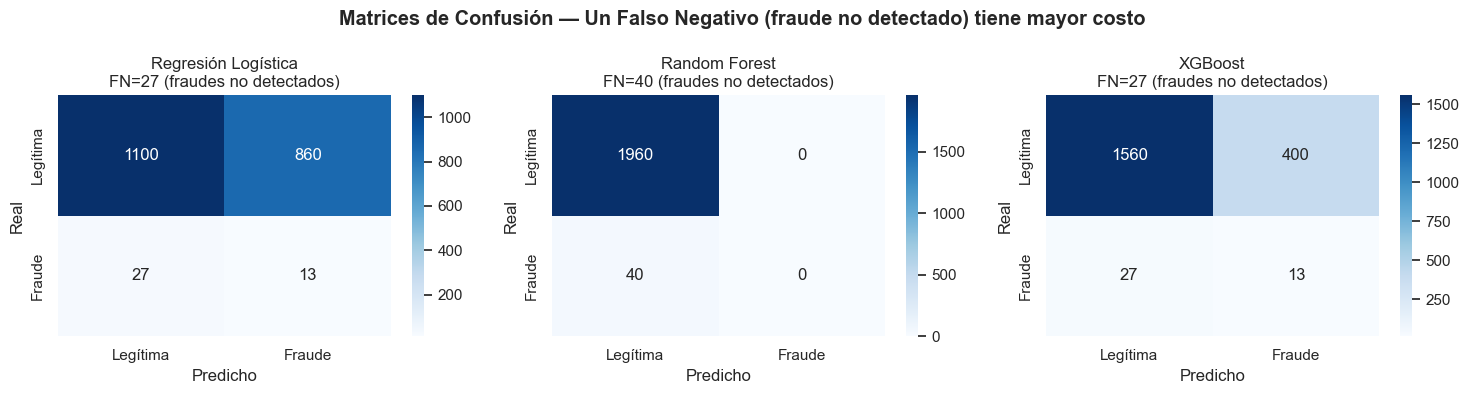

In [57]:
# NOTA: best_rl, best_rf, best_xgb son ahora Pipelines completos (preprocessor + sampler + classifier).
# Por eso pasamos X_test (sin transformar). El Pipeline aplica internamente .transform().

modelos = [('Regresión Logística', best_rl),
           ('Random Forest',       best_rf),
           ('XGBoost',             best_xgb)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, modelo) in zip(axes, modelos):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legítima', 'Fraude'],
                yticklabels=['Legítima', 'Fraude'])
    ax.set_title(f'{nombre}\nFN={cm[1,0]} (fraudes no detectados)')
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión — Un Falso Negativo (fraude no detectado) tiene mayor costo',
             fontweight='bold')
plt.tight_layout()
plt.show()

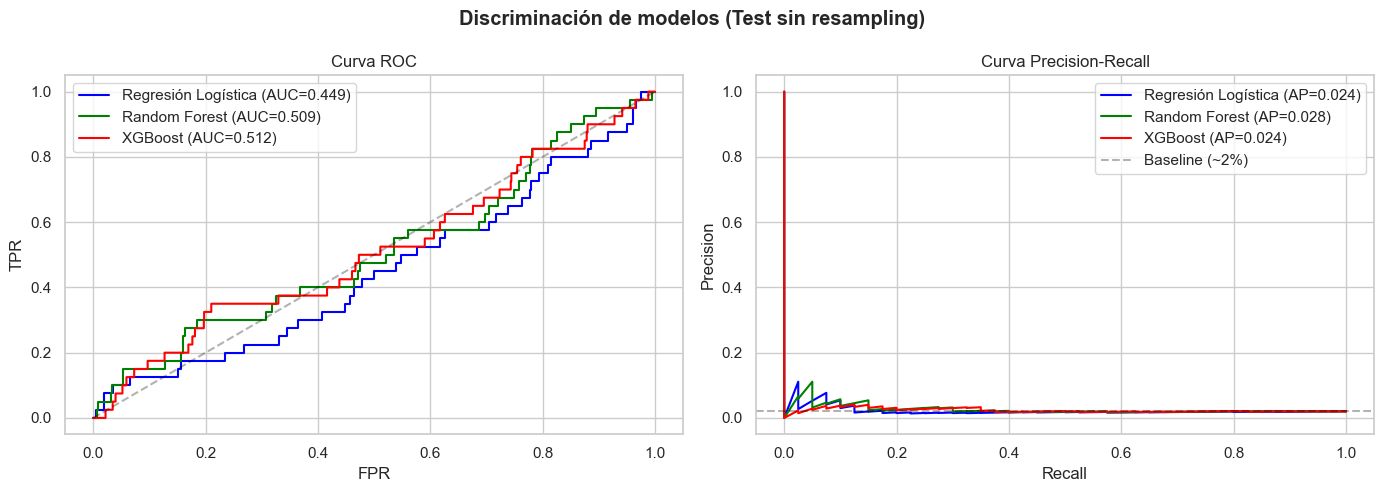

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['blue', 'green', 'red']

for (nombre, modelo), color in zip(modelos, colors):
    y_proba = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=color,
                 label=f'{nombre} (AUC={roc_auc_score(y_test, y_proba):.3f})')

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(rec, prec, color=color,
                 label=f'{nombre} (AP={average_precision_score(y_test, y_proba):.3f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_title('Curva ROC'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend()

axes[1].axhline(y=0.02, color='black', linestyle='--', alpha=0.3, label='Baseline (~2%)')
axes[1].set_title('Curva Precision-Recall')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend()

plt.suptitle('Discriminación de modelos (Test sin resampling)', fontweight='bold')
plt.tight_layout()
plt.show()

Tabla de umbrales operativos (sobre TEST):


,Escenario,Umbral,Precision,Recall,F1,Alertas/Test,Alertas_x10k_tx,FP_Test,FN_Test
0,F1 máx,0.7369,0.0769,0.075,0.0759,39,195,36,37
1,Recall>=0.80,0.3538,0.0196,0.800,0.0383,1631,8155,1599,8
2,Capacidad mesa (5%),0.6888,0.0400,0.100,0.0571,100,500,96,36



UMBRAL OPERATIVO RECOMENDADO: 0.6888
Motivo: Capacidad de mesa (5%): con AUC bajo, priorizar control operativo evita saturar al equipo con falsas alarmas.


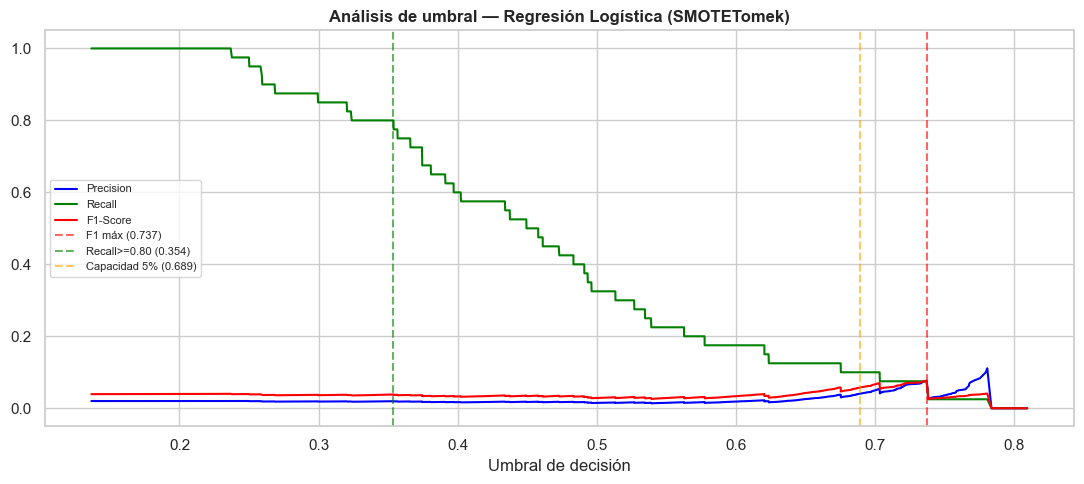

In [59]:
# ============================================================
# 3 ESCENARIOS DE UMBRAL OPERATIVO sobre el modelo final
#   - F1 máx                 (estadístico)
#   - Recall >= 0.80         (priorizar capturar fraude)
#   - Capacidad mesa (5%)    (limitar carga del equipo)
# ============================================================

y_proba_final = modelo_final.predict_proba(X_test)[:, 1]
prec, rec, umbrales = precision_recall_curve(y_test, y_proba_final)
f1_arr = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)

# Escenario 1: F1 máx
idx_f1 = int(np.argmax(f1_arr))
u_f1 = float(umbrales[idx_f1])

# Escenario 2: capturar al menos 80% del fraude
target_recall = 0.80
candidatos = np.where(rec[:-1] >= target_recall)[0]
idx_rec = int(candidatos[-1]) if len(candidatos) > 0 else int(np.argmax(rec[:-1]))
u_rec = float(umbrales[idx_rec])

# Escenario 3: capacidad de mesa (5% del volumen)
capacidad_pct = 0.05
n_alertas = int(round(capacidad_pct * len(y_test)))
orden = np.argsort(-y_proba_final)[:n_alertas]
u_cap = float(np.min(y_proba_final[orden]))
y_pred_cap = (y_proba_final >= u_cap).astype(int)
prec_cap = (y_pred_cap & y_test.values).sum() / max(y_pred_cap.sum(), 1)
rec_cap  = (y_pred_cap & y_test.values).sum() / max(y_test.sum(), 1)
f1_cap   = 2 * prec_cap * rec_cap / max(prec_cap + rec_cap, 1e-9)

def _resumen(nombre, u, p, r, f):
    y_pred = (y_proba_final >= u).astype(int)
    alerts = int(y_pred.sum())
    return {
        'Escenario': nombre, 'Umbral': u,
        'Precision': p, 'Recall': r, 'F1': f,
        'Alertas/Test': alerts,
        'Alertas_x10k_tx': int(round(alerts / len(y_test) * 10_000)),
        'FP_Test': int(((y_pred==1) & (y_test.values==0)).sum()),
        'FN_Test': int(((y_pred==0) & (y_test.values==1)).sum()),
    }

tabla_umbrales = pd.DataFrame([
    _resumen('F1 máx',              u_f1,  prec[idx_f1],  rec[idx_f1],  f1_arr[idx_f1]),
    _resumen('Recall>=0.80',        u_rec, prec[idx_rec], rec[idx_rec], f1_arr[idx_rec]),
    _resumen('Capacidad mesa (5%)', u_cap, prec_cap,      rec_cap,      f1_cap),
])
print("Tabla de umbrales operativos (sobre TEST):")
display(tabla_umbrales.round(4))

# Selección del umbral OPERATIVO recomendado
if bandera_roja:
    umbral_op = u_cap
    motivo_umbral = ("Capacidad de mesa (5%): con AUC bajo, priorizar control "
                     "operativo evita saturar al equipo con falsas alarmas.")
else:
    umbral_op = u_f1 if rec[idx_f1] >= 0.50 else u_rec
    motivo_umbral = ("F1 máx priorizando Recall>=0.50; si no se alcanza, "
                     "fijar Recall>=0.80 (costo_FN >> costo_FP).")

print(f"\nUMBRAL OPERATIVO RECOMENDADO: {umbral_op:.4f}")
print(f"Motivo: {motivo_umbral}")

# Aliases de retro-compatibilidad para celdas posteriores del notebook
umbral_opt = umbral_op
y_proba_cand = y_proba_final
nombre_mejor_auc = nombre_final
idx_opt = idx_f1 if umbral_op == u_f1 else (idx_rec if umbral_op == u_rec else None)

plt.figure(figsize=(11, 5))
plt.plot(umbrales, prec[:-1], label='Precision', color='blue')
plt.plot(umbrales, rec[:-1],  label='Recall',    color='green')
plt.plot(umbrales, f1_arr,    label='F1-Score',  color='red')
plt.axvline(u_f1,  color='red',    linestyle='--', alpha=0.6, label=f'F1 máx ({u_f1:.3f})')
plt.axvline(u_rec, color='green',  linestyle='--', alpha=0.6, label=f'Recall>=0.80 ({u_rec:.3f})')
plt.axvline(u_cap, color='orange', linestyle='--', alpha=0.6, label=f'Capacidad 5% ({u_cap:.3f})')
plt.title(f'Análisis de umbral — {nombre_final} ({estrategia_final})', fontweight='bold')
plt.xlabel('Umbral de decisión'); plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

In [60]:
# Métricas de los 3 modelos en TEST con el umbral operativo seleccionado
resultados = [evaluar_modelo(n, m, X_test, y_test, umbral=umbral_op)
              for n, m in modelos]
df_res = pd.DataFrame(resultados).set_index('Modelo').round(4)
display(df_res.style
        .highlight_max(axis=0, color='lightgreen')
        .highlight_min(axis=0, color='#ffcccc'))

print(f"\nModelo final ya seleccionado por AUC-PR + Parsimonia: {nombre_final} ({estrategia_final})")
print(f"Umbral operativo aplicado: {umbral_op:.4f}")

,Recall,F1,AUC-ROC,AUC-PR,Umbral
Modelo,,,,,
Regresión Logística,0.100000,0.057100,0.448700,0.024200,0.688800
Random Forest,0.000000,0.000000,0.508600,0.028000,0.688800
XGBoost,0.000000,0.000000,0.512200,0.024400,0.688800



Modelo final ya seleccionado por AUC-PR + Parsimonia: Regresión Logística (SMOTETomek)
Umbral operativo aplicado: 0.6888


In [61]:
def calcular_psi(score_train, score_test, bins=10):
    """PSI < 0.1: estable | 0.10-0.25: monitorear | > 0.25: inestable"""
    breaks   = np.unique(np.percentile(score_train, np.linspace(0, 100, bins + 1)))
    pct_tr   = np.histogram(score_train, bins=breaks)[0] / len(score_train) + 1e-6
    pct_te   = np.histogram(score_test,  bins=breaks)[0] / len(score_test)  + 1e-6
    return float(np.sum((pct_te - pct_tr) * np.log(pct_te / pct_tr)))

# PSI sobre las probabilidades del modelo final (Pipeline).
# Comparamos train original (sin resampling) vs test, ambos en distribución real.
psi_val = calcular_psi(
    modelo_final.predict_proba(X_train)[:, 1],
    modelo_final.predict_proba(X_test)[:, 1],
)

estado = "ESTABLE" if psi_val < 0.1 else "MONITOREAR" if psi_val < 0.25 else "INESTABLE"
print(f"PSI del modelo final ({nombre_final}, {estrategia_final}): {psi_val:.4f} = {estado}")
print("PSI calculado sobre train original sin resampling vs test.")

PSI del modelo final (Regresión Logística, SMOTETomek): 0.0133 = ESTABLE
PSI calculado sobre train original sin resampling vs test.


## Módulo 5: Interpretabilidad con SHAP

SHAP (SHapley Additive exPlanations) está basado en la Teoría de Juegos.
Asigna a cada variable una contribución marginal exacta a la predicción.

- **Valor Base (E[f(x)]):** salida promedio del modelo en escala log-odds.
- **Valor SHAP:** cuánto suma o resta cada variable para llegar a la predicción final.
- **Probabilidad base:** se obtiene aplicando sigmoide al valor base en log-odds.

Se generan 3 visualizaciones:
1. **Feature Importance (barras):** importancia global
2. **Beeswarm plot:** magnitud y dirección (el "gráfico estrella")
3. **Waterfall plot:** explicación de un caso concreto de fraude

In [62]:
# Reconstruimos los nombres de features post-OneHot a partir del preprocessor
# YA AJUSTADO dentro del Pipeline final (no usamos el global, ese podría no estar fitted).
fitted_pre = modelo_final.named_steps['preprocessor']
cat_names  = list(fitted_pre.named_transformers_['cat']
                  .named_steps['onehot'].get_feature_names_out(cat_features))
feat_names = list(num_features) + cat_names

# Transformamos manualmente con el preprocessor ya ajustado para alimentar SHAP
X_train_prep_for_shap = fitted_pre.transform(X_train)
X_test_prep_for_shap  = fitted_pre.transform(X_test)

n_shap  = min(500, X_test_prep_for_shap.shape[0])
X_shap  = X_test_prep_for_shap[:n_shap]

# Extraemos el clasificador puro del Pipeline para que shap.Explainer auto-seleccione
# LinearExplainer (RL) o TreeExplainer (RF/XGBoost) correctamente.
clf_extracted = modelo_final.named_steps['classifier']
explainer = shap.Explainer(clf_extracted, X_train_prep_for_shap, feature_names=feat_names)
shap_values = explainer(X_shap)

base_log_odds = float(np.mean(shap_values.base_values))
base_prob = 1 / (1 + np.exp(-base_log_odds))

print(f"SHAP calculado sobre {n_shap} muestras del test.")
print(f"Valor base (E[f(x)]) en log-odds: {base_log_odds:.4f}")
print(f"Probabilidad base aproximada (sigmoide): {base_prob:.2%}")

SHAP calculado sobre 500 muestras del test.
Valor base (E[f(x)]) en log-odds: -0.2461
Probabilidad base aproximada (sigmoide): 43.88%


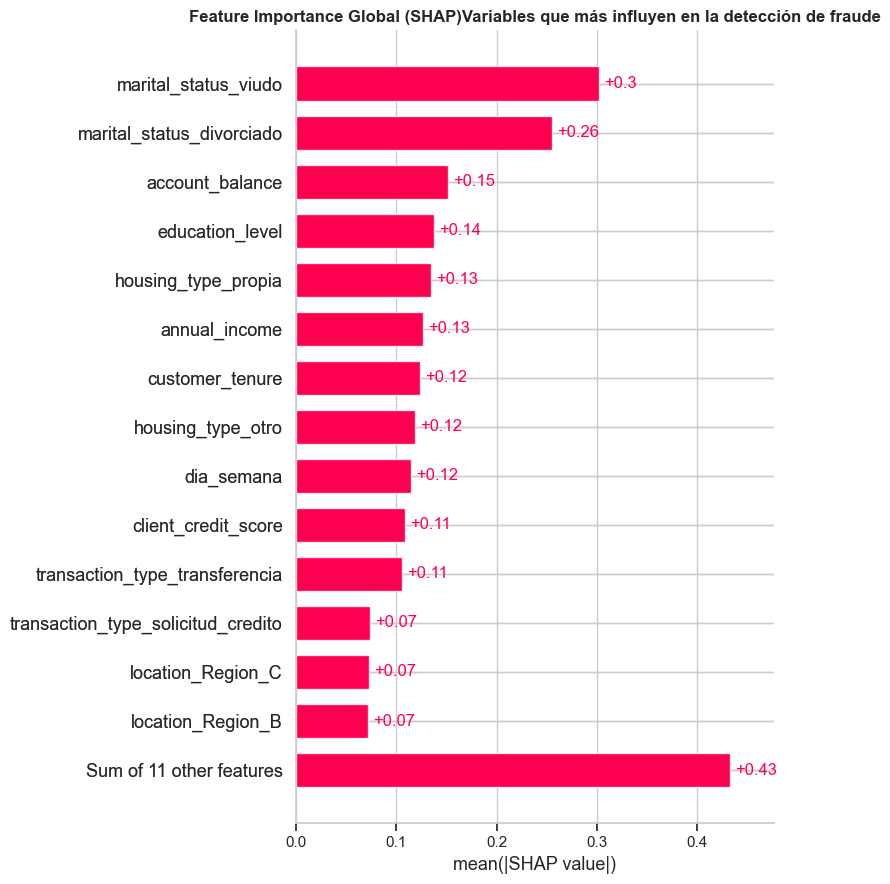

In [63]:
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Feature Importance Global (SHAP)'
          'Variables que más influyen en la detección de fraude',
          fontweight='bold')
plt.tight_layout()
plt.show()

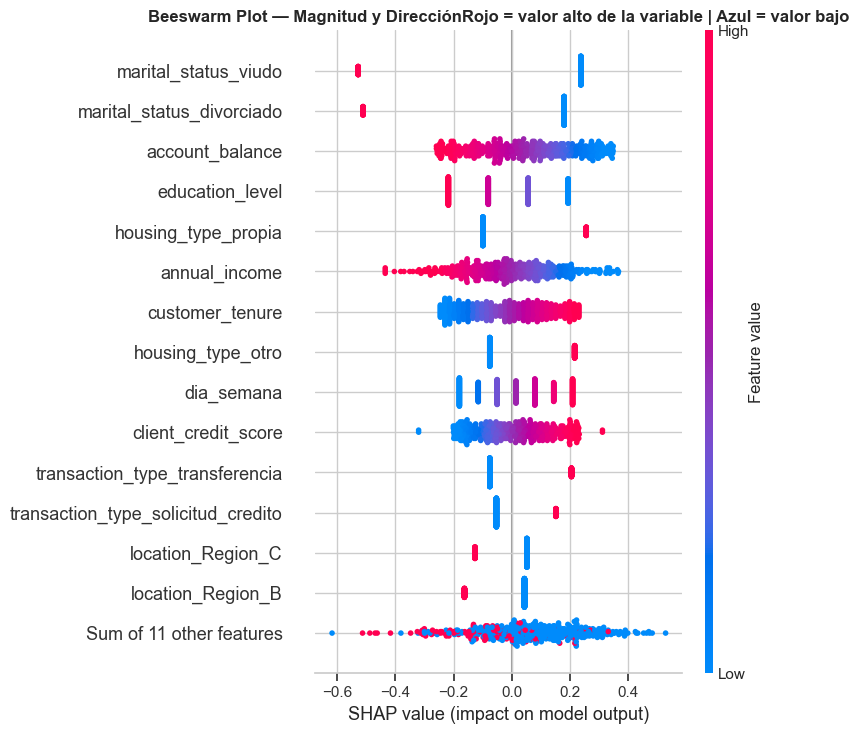

Eje X: Impacto en predicción (>0 aumenta prob. fraude, <0 la reduce)
Eje Y: Variables ordenadas por importancia global


In [64]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('Beeswarm Plot — Magnitud y Dirección'
          'Rojo = valor alto de la variable | Azul = valor bajo',
          fontweight='bold')
plt.tight_layout()
plt.show()
print("Eje X: Impacto en predicción (>0 aumenta prob. fraude, <0 la reduce)")
print("Eje Y: Variables ordenadas por importancia global")

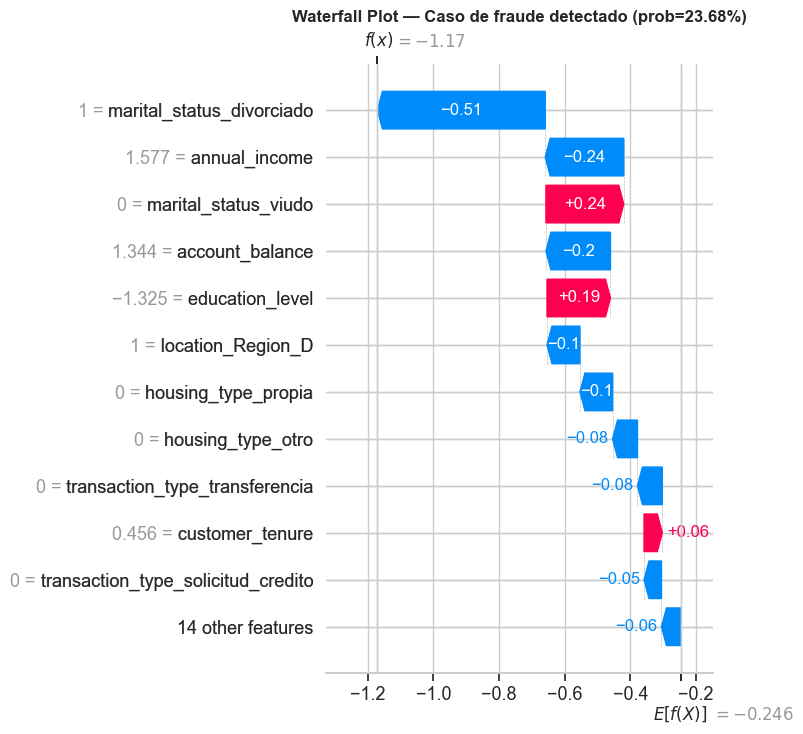

Probabilidad de fraude para este cliente: 23.68%
Comparado con el umbral operativo (68.88%): no detectado.
Barras rojas: variables que aumentan el riesgo.
Barras azules: variables que reducen el riesgo.
Este gráfico puede mostrarse directamente al Comité de Riesgos.


In [65]:
idx_fraudes = np.where(y_test.values[:n_shap] == 1)[0]
if len(idx_fraudes) > 0:
    idx  = int(idx_fraudes[0])
    # OJO: pasamos la fila ORIGINAL (sin transformar) al Pipeline modelo_final.
    prob = float(modelo_final.predict_proba(X_test.iloc[[idx]])[0, 1])
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[idx], max_display=12, show=False)
    plt.title(f'Waterfall Plot — Caso de fraude detectado (prob={prob:.2%})',
              fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Probabilidad de fraude para este cliente: {prob:.2%}")
    print(f"Comparado con el umbral operativo ({umbral_op:.2%}): "
          f"{'detectado' if prob >= umbral_op else 'no detectado'}.")
    print("Barras rojas: variables que aumentan el riesgo.")
    print("Barras azules: variables que reducen el riesgo.")
    print("Este gráfico puede mostrarse directamente al Comité de Riesgos.")

## Módulo 6: Conclusiones y Recomendaciones Operativas

In [66]:
y_pred_final = (modelo_final.predict_proba(X_test)[:, 1] >= umbral_op).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
TN, FP, FN, TP = int(cm_final[0,0]), int(cm_final[0,1]), int(cm_final[1,0]), int(cm_final[1,1])
prec_op = TP / max(TP + FP, 1)
rec_op  = TP / max(TP + FN, 1)
f1_op   = 2 * prec_op * rec_op / max(prec_op + rec_op, 1e-9)

alertas_10k            = int(round(y_pred_final.mean() * 10_000))
fraudes_detectados_10k = int(round(alertas_10k * prec_op))
falsas_alarmas_10k     = max(alertas_10k - fraudes_detectados_10k, 0)

print("=" * 70)
print("   RESUMEN EJECUTIVO — MODELO DE DETECCIÓN DE FRAUDE  (REVISADO)")
print("=" * 70)
print(f" DATASET             : 10,000 tx | {int(y.sum())} fraudes ({y.mean()*100:.2f}%)")
print(f" CONFIGURACIONES     : 3 modelos x 3 estrategias = 9 (Pipeline imblearn en CV)")
print(f" SCORING DEL CV      : average_precision (AUC-PR)")
print(f" MODELO SELECCIONADO : {nombre_final} ({estrategia_final})")
print(f" AUC-PR  (Test)      : {ap_final:.4f}")
print(f" AUC-ROC (Test)      : {auc_final:.4f}   (Gini = {2*auc_final-1:+.4f})")
print(f" UMBRAL OPERATIVO    : {umbral_op:.4f}  -> {motivo_umbral}")
print(f" Precision @ umbral  : {prec_op:.4f}")
print(f" Recall    @ umbral  : {rec_op:.4f}")
print(f" F1-Score  @ umbral  : {f1_op:.4f}")
print(f" Matriz Confusión    : TN={TN} FP={FP} FN={FN} TP={TP}")
estado_psi = "Estable" if psi_val < 0.1 else "Monitorear" if psi_val < 0.25 else "Revisar"
print(f" PSI                 : {psi_val:.4f}  ({estado_psi})")
print("-" * 70)
print(classification_report(y_test, y_pred_final, target_names=['Legítima', 'Fraude']))
print(f" Operativa diaria (escenario 10,000 tx/día):")
print(f"   - Alertas esperadas      : {alertas_10k:,}")
print(f"   - Fraudes detectados     : {fraudes_detectados_10k:,}")
print(f"   - Falsas alarmas         : {falsas_alarmas_10k:,}")
print(f"   - % falsas / alertas     : {(1-prec_op)*100:.0f}%")
print("-" * 70)
if bandera_roja:
    print(" RECOMENDACIÓN AL COMITÉ DE RIESGOS:")
    print("  1. NO desplegar en producción (AUC < 0.55 = no discrimina).")
    print("  2. Fase 2 con foco en DATOS, no en algoritmo:")
    print("     - Variables comportamentales (velocidad, device, geo).")
    print("     - Ampliar ventana histórica (>1,000 fraudes).")
    print("     - Fuentes externas (buró, listas negras, AML).")
    print("  3. Pipeline en modo 'shadow' como termómetro de calidad de datos.")
    print("  4. Mantener motor de reglas vigente.")
else:
    print(" RECOMENDACIÓN AL COMITÉ DE RIESGOS:")
    print("  1. Desplegar en MODO SHADOW por 30 días.")
    print("  2. Tablero diario Recall/Precision/% falsas alarmas.")
    print("  3. PSI mensual (umbrales 0.10/0.25); reentrenar si > 0.25.")
    print("  4. Reentrenamiento trimestral programado.")
    print("  5. Reporte trimestral con SHAP + análisis de fairness.")
print("=" * 70)

   RESUMEN EJECUTIVO — MODELO DE DETECCIÓN DE FRAUDE  (REVISADO)
 DATASET             : 10,000 tx | 200 fraudes (2.00%)
 CONFIGURACIONES     : 3 modelos x 3 estrategias = 9 (Pipeline imblearn en CV)
 SCORING DEL CV      : average_precision (AUC-PR)
 MODELO SELECCIONADO : Regresión Logística (SMOTETomek)
 AUC-PR  (Test)      : 0.0242
 AUC-ROC (Test)      : 0.4487   (Gini = -0.1026)
 UMBRAL OPERATIVO    : 0.6888  -> Capacidad de mesa (5%): con AUC bajo, priorizar control operativo evita saturar al equipo con falsas alarmas.
 Precision @ umbral  : 0.0400
 Recall    @ umbral  : 0.1000
 F1-Score  @ umbral  : 0.0571
 Matriz Confusión    : TN=1864 FP=96 FN=36 TP=4
 PSI                 : 0.0133  (Estable)
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Legítima       0.98      0.95      0.97      1960
      Fraude       0.04      0.10      0.06        40

    accuracy                           0.93      2000
   m